In [23]:
import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt

dict_keys(['__header__', '__version__', '__globals__', 'Fs', 'recordName', 'targetsQRS', 'targetsRR', 'qrs', 'rr', 'afBounds'])
(40232,)
[1.076 1.116 1.116 ... 0.972 0.98  0.96 ]


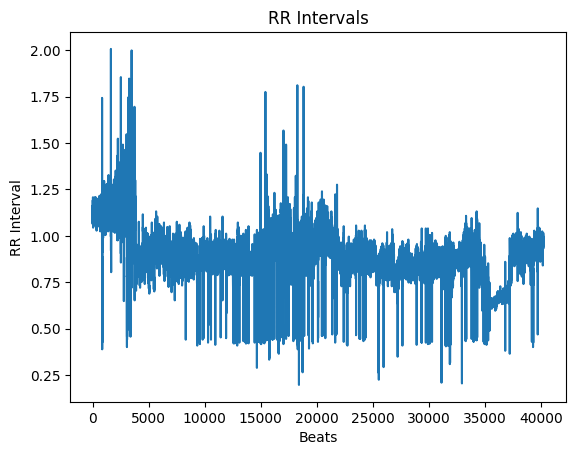

In [28]:
data1 = loadmat('afdb_1.mat')
print(data1.keys())
rr = data1['rr'].flatten()
target = data1['targetsRR'].flatten()

print(rr.shape)
print(rr)

plt.figure()
plt.plot(rr.flatten())
plt.title("RR Intervals")
plt.xlabel("Beats")
plt.ylabel("RR Interval")
plt.show()


In [25]:
def evaluate(target, detect):
    TP = np.sum((target == 1) & np.sum(detect == 1))
    TN = np.sum((target == 0) & np.sum(detect == 0))
    FP = np.sum((target == 0) & np.sum(detect == 1))
    FN = np.sum((target == 1) & np.sum(detect == 0))

    sensitivity = TP / (TP + FN)
    specificity = TN / (TN + FP)

    return sensitivity, specificity


/var/folders/gq/clgp99xs5c713l_6jqnvjw0c0000gn/T/ipykernel_11508/222749865.py:7: RuntimeWarning: invalid value encountered in scalar divide
  sensitivity = TP / (TP + FN)
/var/folders/gq/clgp99xs5c713l_6jqnvjw0c0000gn/T/ipykernel_11508/222749865.py:8: RuntimeWarning: invalid value encountered in scalar divide
  specificity = TN / (TN + FP)


(np.float64(nan), np.float64(nan))


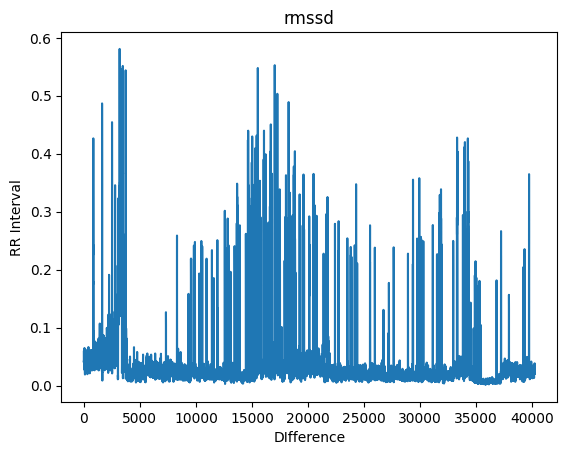

In [31]:
window_size = 10
threshold = 0
rmssd_values = []
detectRR = []
for i in range(len(rr)-window_size):
    window = rr[i:i+10]
    diff = np.diff(window)
    rmssd = np.sqrt(np.mean(diff**2))
    rmssd_values.append(rmssd)

    if rmssd > threshold:
        detectRR.append(1)
    else:
        detectRR.append(0)
        
d = evaluate(target, rmssd_values)

print(d)
plt.figure()
plt.plot(rmssd_values)
plt.title("rmssd")
plt.xlabel("DIfference")
plt.ylabel("RR Interval")
plt.show()



